# Replicating the Italian day-ahead market with OpenEUPHEMIA

[EUPHEMIA](https://www.nemo-committee.eu/sdac) clears the European day-ahead
market: it maximizes welfare over every submitted order subject to network
constraints, and the outcome — a price per zone, a flow per link — settles
billions of euros a year. It's publicly described but closed-source.

Here we build the seven Italian bidding zones by hand for one day, then
compare four ways of handling the flows against a full month of published
results.

In [1]:
import pathlib
import sys

if "google.colab" in sys.modules:
    !git clone -q https://github.com/rebase-energy/OpenEUPHEMIA.git
    %pip install -q "./OpenEUPHEMIA[notebook]"
    ROOT = pathlib.Path("OpenEUPHEMIA")
else:
    ROOT = next(
        parent
        for parent in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
        if (parent / "data" / "italy").is_dir()
    )

sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "italy" / "2025-04"
print("repository root:", ROOT)

repository root: /Users/sebaheg/Documents/Github/OpenEUPHEMIA


## The inputs

Five tidy tables from GME's public publications, committed under
[`data/italy`](../data/italy) — no data-collection code, just datasets.
The Italian prices and the flows between Italian zones are the targets
and are never given to the solver.

| Table | What it is |
|---|---|
| `bid-curves` | order book, aggregated: zone, hour, side, price step |
| `transfer-capacities` | link limit, internal and cross-border |
| `internal-transfer-capacities` | the 6 internal links, shaped for `set_ntc` |
| `published-prices` | Italian zones **and** their neighbours |
| `published-flows` | scheduled flow, each of the 6 internal links — **target** |

In [2]:
import pandas as pd

bid_curves = pd.read_csv(DATA / "bid-curves.csv.gz")
transfer_capacities = pd.read_csv(DATA / "transfer-capacities.csv.gz")
internal_capacities = pd.read_csv(DATA / "internal-transfer-capacities.csv.gz")
published_prices = pd.read_csv(DATA / "published-prices.csv.gz")
published_flows = pd.read_csv(DATA / "published-flows.csv.gz")

DAY = "2025-04-01"
print(f"{len(bid_curves):,} curve rows over {bid_curves.delivery_day.nunique()} days")

535,765 curve rows over 30 days


## Build one day by hand

Zones and links on the `PowerMarket` itself, aggregated bid curves per
zone and hour, then `set_ntc` for the internal transfer limits.

In [3]:
from openeuphemia import PowerMarket, bid_curves_from_table
from openeuphemia.areas.italy import ITALY_PRICE_AREAS
from openeuphemia.areas.italy.replication import rows_for_day

links = sorted({(r.from_zone, r.to_zone) for r in internal_capacities.itertuples()})

market = PowerMarket(
    name="italy", delivery_day=DAY, zones=list(ITALY_PRICE_AREAS),
    interconnectors=links, periods=list(range(1, 25)),
)
curves = bid_curves_from_table(rows_for_day(bid_curves, DAY))
for (period, zone), sides in curves.items():
    market.add_bid_curve(zone=zone, period=period, **sides)
for row in rows_for_day(internal_capacities, DAY).itertuples():
    market.set_ntc(row.from_zone, row.to_zone, period=row.period,
                    forward_capacity_mwh=row.forward_capacity_mwh,
                    reverse_capacity_mwh=row.reverse_capacity_mwh)

print(f"{len(curves)} zone-hours -> {len(market.orders):,} orders")

168 zone-hours -> 18,060 orders


NORD's bid curve, at four different hours of the day — the same zone,
but demand and supply both shift with the time of day:

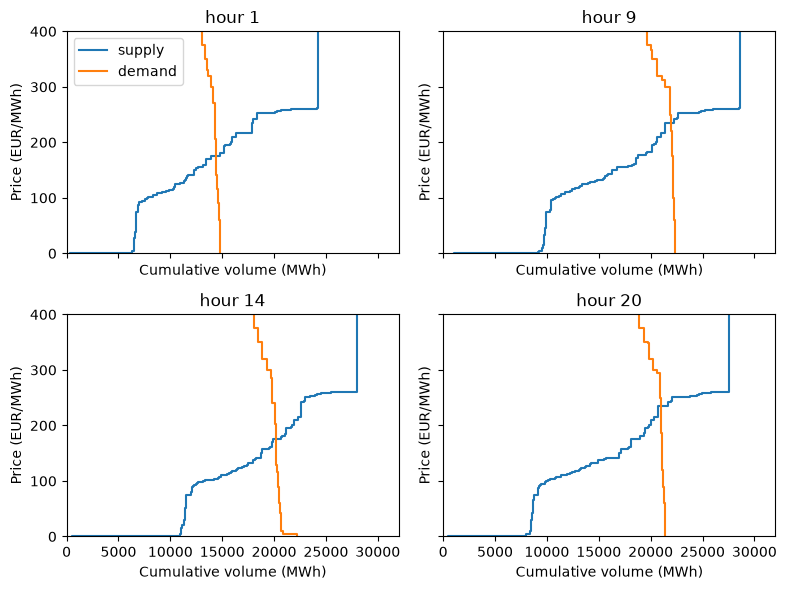

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)
for hour, ax in zip([1, 9, 14, 20], axes.flat):
    curves[(hour, "NORD")]["supply"].plot(ax=ax, label="supply")
    curves[(hour, "NORD")]["demand"].plot(ax=ax, label="demand")
    ax.set_title(f"hour {hour}")
axes[0, 0].set_xlim(0, 32_000); axes[0, 0].set_ylim(0, 400)
axes[0, 0].legend()
fig.tight_layout()
plt.show()

## Close the border, clear, compare

Italy trades with six neighbours. `add_fixed_price_boundary` makes each
border a *price taker* at the neighbour's published price — free to trade
within the published capacity, no exchange data needed. (`add_fixed_flow_boundary`
is the other option: pin a border at a known exchange instead.)

In [5]:
from openeuphemia.areas.italy import compare_prices, summarize_price_comparison
from openeuphemia.areas.italy.replication import (
    external_boundary_prices, external_capacity_bounds, price_mapping,
)

prices_by_zone = price_mapping(published_prices, delivery_day=DAY)
neighbour_prices = {k: v for k, v in prices_by_zone.items() if k[1] not in ITALY_PRICE_AREAS}
border_prices, _ = external_boundary_prices(
    external_capacity_bounds(transfer_capacities, delivery_day=DAY, zones=ITALY_PRICE_AREAS),
    neighbour_prices,
)
for row in border_prices.itertuples():
    market.add_fixed_price_boundary(
        id=row.id, period=row.period, zone=row.zone, external_zone=row.external_zone,
        price_eur_per_mwh=row.price_eur_per_mwh,
        import_capacity_mwh=row.import_capacity_mwh, export_capacity_mwh=row.export_capacity_mwh,
    )

result = market.clear(method="per-period-lp")
italian_prices = {k: v for k, v in prices_by_zone.items() if k[1] in ITALY_PRICE_AREAS}
comparison = compare_prices(result.prices, italian_prices, delivery_day=DAY)
summarize_price_comparison(comparison)

{'price_rows': 168,
 'matched_rows': 168,
 'exact_rows': 168,
 'price_mae_eur_per_mwh': 0.0,
 'price_max_abs_error_eur_per_mwh': 0.0}

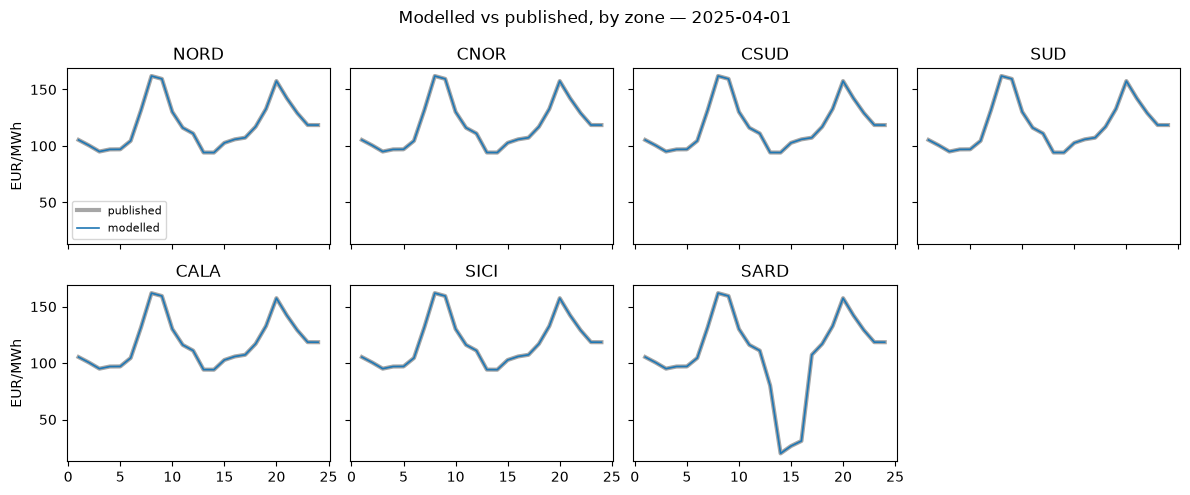

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
for zone, ax in zip(ITALY_PRICE_AREAS, axes.flat):
    rows = comparison[comparison.zone == zone].sort_values("period")
    ax.plot(rows.period, rows.published_price_eur_per_mwh, lw=3, alpha=0.35, color="black", label="published")
    ax.plot(rows.period, rows.modelled_price_eur_per_mwh, lw=1.2, color="tab:blue", label="modelled")
    ax.set_title(zone)
axes.flat[-1].axis("off")
axes[0, 0].set_ylabel("EUR/MWh"); axes[1, 0].set_ylabel("EUR/MWh")
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Modelled vs published, by zone — {DAY}")
fig.tight_layout()
plt.show()

Every panel overlaps exactly: 168 of 168 hours exact. Welfare
maximization pins down a unique price, and the neighbours' published
prices alone stand in for the rest of Europe.

## Four ways to handle the flows

Prices are solved. Flows are not: with the border a free price-taker,
many exchange patterns are equally optimal, so which flow the model
returns depends on the **selection rule** applied on top — a secondary
objective that never touches the prices. `replicate_italy_day` runs the
build above end to end, with `flow_selection` as the knob:

- `None` — an arbitrary optimal vertex.
- `"volume-max"` — EUPHEMIA's documented rule: trade zero-surplus matches too.
- `"pro-rata"` — reverse-engineered from published outcomes: split tied
  acceptance in proportion to submitted volume.
- `"anchored"` — minimize distance to the published flows directly. This
  reads the answer, so it's a reference bound, not a prediction.

In [7]:
from openeuphemia.areas.italy import delivery_days, replicate_italy_day, summarize_flow_comparison

RULES = [None, "volume-max", "pro-rata", "anchored"]
inputs = dict(
    bid_curves=bid_curves, transfer_capacities=transfer_capacities,
    published_prices=published_prices, published_flows=published_flows,
)
days = delivery_days(bid_curves)

overview = []
for rule in RULES:
    results = [
        replicate_italy_day(delivery_day=day, boundary="prices", flow_selection=rule, **inputs)
        for day in days
    ]
    prices = pd.concat([r.price_comparison for r in results], ignore_index=True)
    flows = pd.concat([r.flow_comparison for r in results], ignore_index=True)
    price_stats, flow_stats = summarize_price_comparison(prices), summarize_flow_comparison(flows)
    overview.append({
        "rule": rule or "none",
        "price MAE (EUR/MWh)": price_stats["price_mae_eur_per_mwh"],
        "flow MAE (MWh)": flow_stats["flow_mae_mwh"],
        "flow max error (MWh)": flow_stats["flow_max_abs_error_mwh"],
    })

overview = pd.DataFrame(overview)
overview

,rule,price MAE (EUR/MWh),flow MAE (MWh),flow max error (MWh)
0,none,0.0,2.065281e+03,8.165908e+03
1,volume-max,0.0,2.065193e+03,8.165908e+03
2,pro-rata,0.0,2.065228e+03,8.165908e+03
3,anchored,0.0,4.503648e-14,2.046363e-12


Prices stay exact for every rule — the price-taking boundary decides
them before any selection is applied. The flow error bars below show the
mean (dot) and worst-case (whisker) error per rule, on a log scale.

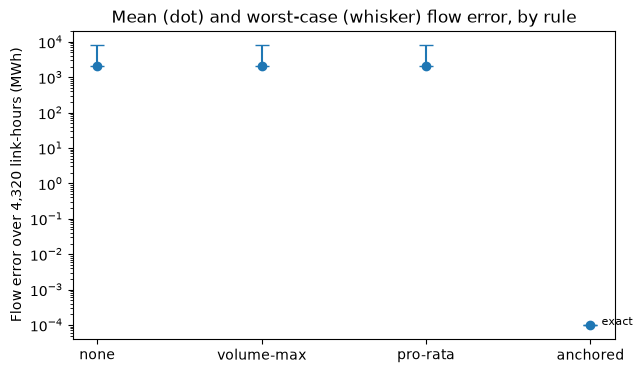

In [8]:
import numpy as np

FLOOR = 1e-4  # log axes can't draw a true zero; floored points are exact

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(overview))
mae = overview["flow MAE (MWh)"].clip(lower=FLOOR)
worst = overview["flow max error (MWh)"].clip(lower=FLOOR)
ax.errorbar(x, mae, yerr=[[0] * len(x), worst - mae], fmt="o", capsize=5, color="tab:blue")
for i, (m, w) in enumerate(zip(overview["flow MAE (MWh)"], overview["flow max error (MWh)"])):
    if w < 1e-6:
        ax.annotate("exact", (i, FLOOR), textcoords="offset points", xytext=(8, 0), fontsize=8)
ax.set_yscale("log")
ax.set_xticks(x, overview["rule"])
ax.set_ylabel("Flow error over 4,320 link-hours (MWh)")
ax.set_title("Mean (dot) and worst-case (whisker) flow error, by rule")
plt.show()

## What this shows

Blind rules only fix *how tied acceptance splits between zones* — they
don't touch the border's free volume, so `volume-max` and `pro-rata`
barely move the needle here (unlike under a fixed-exchange boundary,
where pro-rata alone closes most of the gap). Only `anchored` can, since
minimizing distance to the target lets the border's zero-cost freedom
absorb whatever the target flow needs — and it lands **exactly** on every
one of the 4,320 link-hours, with prices still exact throughout.

That matches the best flow-closing result from earlier validation work —
and slightly improves on it, since it needs no boundary-clipping
heuristics to get there. The tables — curves, capacities, published
prices — are all any other bidding zone needs; adding a region means
preparing them and proving the clearing reproduces what was published.